# Analyze One-At-A-Time Ensembles

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib

import fates_calibration_library.parameter_generation as param
import fates_calibration_library.oaat_functions as oaat
import fates_calibration_library.plotting_functions as plotting
import fates_calibration_library.utils as utils
import fates_calibration_library.clm_functions as clm

In [2]:
import importlib

## Set Up
File locations and ensemble information

In [3]:
# parameter directory
param_dir = '/glade/work/afoster/FATES_calibration/parameter_files'

# history output directory
hist_dir = '/glade/work/afoster/FATES_calibration/history_files/compiled_files'

# output directory for figures
fig_dir = '/glade/work/afoster/FATES_calibration/figures/oaat_figs'

ensemble_dict = {
    'fates': {
        'param_list': os.path.join(param_dir, "param_list_sci.1.85.1_api.40.0.0.xls"),
        'key': os.path.join(param_dir, 'fates_oaat', 'fates_oaat_key.csv'),
        'name': 'fates_oaat',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'fates_oaat'),
        'param_prefix': 'FATES_OAAT_',
        'default_param': xr.open_dataset(os.path.join(param_dir,
                                                      'fates_params_default_sci.1.81.1_api.38.0.0_crops_vai.nc'))
    },
    'fates_clmpars': {
        'param_list': os.path.join(param_dir, 'CLM5_Parameter_List.csv'),
        'key': os.path.join(param_dir, 'clm6sp_oaat_key.csv'),
        'name': 'fates_oaat_clmpars',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'clm_oaat'),
        'param_prefix': 'CLM6SPoaat',
        'default_param': xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/paramdata/ctsm60_params.c241017.nc'),
        'nlmods_file': pd.read_csv(os.path.join(param_dir, 'clm6sp_nlmods.csv'))
    },
    'clm_btran': {
        'param_list': os.path.join(param_dir, 'CLM5_Parameter_List.csv'),
        'key': os.path.join(param_dir, 'clm6sp_oaat_key.csv'),
        'name': 'clm_oaat',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'clm_oaat'),
        'param_prefix': 'CLM6SPoaat',
        'default_param': xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/paramdata/ctsm60_params.c241017.nc'),
        'nlmods_file': pd.read_csv(os.path.join(param_dir, 'clm6sp_nlmods.csv'))
    }
}
fates = ensemble_dict['fates']
fates_clm = ensemble_dict['fates_clmpars']
clm_btran = ensemble_dict['clm_btran']

# config file with variable information in it
var_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/model_conversion.yaml'
var_dict = utils.get_config_file(var_config)

obs_config_file = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/ilamb_conversion.yaml'
obs_config = utils.get_config_file(obs_config_file)

fates_clm_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/fates_clm_index.yaml'
fates_to_clm = utils.get_config_file(fates_clm_config)

clm_pft_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/clm_index_to_name.yaml'
clm_pfts = utils.get_config_file(clm_pft_config)

## Read in parameter information

In [4]:
# oaat key
fates_key = pd.read_csv(fates['key'], index_col=0)
clm_key = pd.read_csv(clm_btran['key'], header=None)
clm_key.columns = ['ensemble', 'parameter_name', 'type']

fates_param_dat = oaat.get_fates_param_dat(fates['param_list'], fates_key)

clm_param_dat = oaat.get_clm_param_dat(fates_clm['param_list'])

all_params = pd.concat([clm_param_dat.to_pandas().reset_index().drop(columns=['type', 'ensemble']).drop_duplicates(), 
                        fates_param_dat.to_pandas().reset_index().drop(columns=['type', 'ensemble']).drop_duplicates()])

In [5]:
all_fates_params = np.unique(fates_key[fates_key.parameter_name != 'default']['parameter_name'])
all_clm_params = np.unique(clm_key[clm_key.parameter_name != 'default']['parameter_name'])

In [6]:
param_list_name = "param_list_sci.1.85.1_api.40.0.0.xls"
param_list_file = os.path.join(param_dir, param_list_name)
param_dat = param.get_param_dictionary(param_list_file)
main_param = param_dat["main"]
main_param = main_param[main_param['calibrate'] == 'Y']

In [7]:
didnt_do = []
all_pars = main_param.fates_parameter_name.values
for par in all_pars:
    if par not in all_fates_params:
        didnt_do.append(par)

## Analysis

### Global annual means

In [12]:
variables = ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF', 'SOILWATER_10CM',
       'ASA', 'RN', 'BTRANMN', 'QRUNOFF', 'QSOIL', 'QVEGT',
       'QVEGE']

In [13]:
# FATES SP ensemble with FATES parameters
fates_glob = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates['name']}_area_means.nc"),
                                       fates_param_dat, variables, fates['default'])
fates_mean = fates_glob.sel(summation_var='mean')
fates_iav = fates_glob.sel(summation_var='iav')

fates_biome = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates['name']}_biome_area_means.nc"),
                                       fates_param_dat, variables, fates['default'])

In [14]:
# FATES SP ensemble with CLM parameters
fatesclm_glob = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates_clm['name']}_area_means.nc"),
                                       clm_param_dat, variables, fates_clm['default'])
fatesclm_mean = fatesclm_glob.sel(summation_var='mean')
fatesclm_iav = fatesclm_glob.sel(summation_var='iav')

fatesclm_biome = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates_clm['name']}_biome_area_means.nc"),
                                       clm_param_dat, variables, fates_clm['default'])

In [15]:
# combine FATES ensembles into one
fates_glob_combo = oaat.get_combined(fates_glob, fatesclm_glob, 'fates parameters', 'clm parameters')
fates_combo_mean = fates_glob_combo.sel(summation_var='mean')
fates_combo_iav = fates_glob_combo.sel(summation_var='iav')

fates_biome_combo = oaat.get_combined(fates_biome, fatesclm_biome, 'fates parameters', 'clm parameters')

In [16]:
# CLM SP ensemble with CLM parameters (BTRAN)
clmbtran_glob = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{clm_btran['name']}_area_means.nc"),
                                       clm_param_dat, variables, clm_btran['default'])
clmbtran_glob['sim_source'] = 'clm parameters'
clmbtran_mean = clmbtran_glob.sel(summation_var='mean')
clmbtran_iav = clmbtran_glob.sel(summation_var='iav')

clm_biome = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{clm_btran['name']}_biome_area_means.nc"),
                                       clm_param_dat, variables, clm_btran['default'])

In [17]:
clm_ensemble = clmbtran_mean.where(clmbtran_mean.sum_diff > 0.0, drop=True)
clm_ensemble = clm_ensemble.to_pandas().reset_index().drop(columns=['ensemble'])
clm_ensemble['model'] = 'CLM'

fates_ensemble = fates_glob_combo.sel(summation_var='mean').where(fates_glob_combo.sum_diff > 0.0, drop=True)
fates_ensemble = fates_ensemble.to_pandas().reset_index().drop(columns=['ensemble'])
fates_ensemble['model'] = 'FATES'

## Find non-zero parameters

In [18]:
# find non-zero parameters for all simulations
nonzero_params = oaat.get_params(fates_glob, fatesclm_glob, clmbtran_glob)
clm_params = np.unique(np.append(nonzero_params['fates_clm'], nonzero_params['clm_parameters']))

fates_nonzero = fates_param_dat.where(fates_param_dat.parameter_name.isin(nonzero_params['fates_only']), drop=True).to_pandas()
fates_nonzero['type'] = 'FATES'

clmfates_nonzero = clm_param_dat.where(clm_param_dat.parameter_name.isin(nonzero_params['fates_clm']), drop=True).to_pandas()
clmfates_nonzero['type'] = 'CLM'

clm_nonzero = clm_param_dat.where(clm_param_dat.parameter_name.isin(nonzero_params['clm_parameters']), drop=True).to_pandas()
clm_nonzero['type'] = 'CLM'

clm_only = clm_param_dat.where(clm_param_dat.parameter_name.isin(nonzero_params['clm_only']), drop=True).to_pandas()
clm_only['type'] = 'CLM'
clm_only = clm_only.reset_index().drop(columns=['ensemble']).drop_duplicates()

fates_oaat_params = pd.concat([fates_nonzero, clmfates_nonzero])

In [19]:
clm_only.to_csv(os.path.join(hist_dir, 'clm_only_params.csv'))
fates_nonzero.to_csv(os.path.join(hist_dir, 'fates_only_params.csv'))

In [20]:
clm_pars = np.unique(clmbtran_glob.where(clmbtran_glob.sum_diff > 0, drop=True).parameter_name.values)
fates_pars = np.unique(fates_glob_combo.where(fates_glob_combo.sum_diff > 0, drop=True).parameter_name.values)

In [131]:
def plot_model_oaat(ax, param_dat: pd.DataFrame, model: str):
    """Plots a column graph of number of parameters in OAAT ensemble

    Args:
        param_dat (pd.DataFrame): data frame with information about parameters
        model (str): model name for title
    """
    
    # count up totals, update names of subcategory
    param_counts_total = (param_dat.groupby(['category', 'subcategory']).size().reset_index(name='num'))
    param_counts_total['subcategory_label'] = param_counts_total['subcategory'].map(plotting._SUBCATEGORY_LABELS)
    
    # createa pivot table
    pivot = param_counts_total.pivot_table(index=['subcategory_label', 'category'], values='num', fill_value=0)
    
    # re-order subcategory
    subcategory_order = ['Fire', 'Land use', 'Allocation', 'Allometry', 'Decomposition',
                         'Mortality', 'Nutrient uptake', 'Phenology', 'Recruitment',
                         'Respiration', 'Vegetation dynamics', 'Acclimation',
                         'Photosynthesis', 'Vegetation water', 'Radiation', 'Sensible and latent heat',
                         'Soil thermal properties', 'Soil hydraulics', 'Snow']
    
    # get rid of subcategories that are not present
    subcategory_present = param_counts_total['subcategory_label'].unique()
    filtered_order = [s for s in subcategory_order if s in subcategory_present]
    
    subcategory_to_y = {label: i for i, label in enumerate(filtered_order)}
    
    # re-order pivot table
    pivot = pivot.reset_index()
    pivot = pivot[pivot['subcategory_label'].isin(subcategory_order)]
    pivot['y'] = pivot['subcategory_label'].map(subcategory_to_y)
    pivot = pivot.sort_values('y')

    legend_elements = param_col_graph(ax, pivot)
    
    yticks = [subcategory_to_y[label] for label in subcategory_order if label in pivot['subcategory_label'].unique()]
    yticklabels = [label for label in subcategory_order if label in pivot['subcategory_label'].unique()]
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    
    ax.set_xlabel('Number of Parameters')
    ax.set_ylabel('')
    ax.set_title(f'{model} Parameters')

    return legend_elements

def param_col_graph(ax, pivot):
    
    legend_elements = {}
    for _, row in pivot.iterrows():
    
        y = row['y']
        category = row['category']
        val = row['num']
        color = plotting._CATEGORY_COLORS.get(category, '#cccccc')

        ax.barh(y, val, color=color)
        t = ax.text(val - 0.5, y, str(int(val)), va='center', ha='center', 
                fontsize=12, c='white', weight='bold')
        legend_elements[category] = Patch(facecolor=color, label=category)

    return legend_elements

def plot_oaat_params(param_dat_fates: pd.DataFrame, param_dat_clm: pd.DataFrame, param_dat_joint):
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 1, figsize=(10, 20))
    le_fates = plot_model_oaat(axes[0], param_dat_fates, 'FATES Only')
    le_clm = plot_model_oaat(axes[1], param_dat_clm, 'CLM Only')
    le_joint = plot_model_oaat(axes[2], param_dat_joint, 'Joint')
    
    legend_elements = le_fates
    legend_elements.update(le_clm)
    legend_elements.update(le_joint)
    
    handles = legend_elements.values()
    labels = [plotting._CATEGORY_LABELS.get(label, label) for label in legend_elements.keys()]
    axes[1].legend(
        handles=handles,
        labels=labels,
        title=None,
        loc='lower center',
        bbox_to_anchor=(1.2, 0.5),
        ncol=1
    )
    plt.tight_layout()

In [132]:
param_dat_fates = fates_oaat_params[fates_oaat_params.parameter_name.isin(np.append(nonzero_params['fates_only'], 'zsno'))].drop_duplicates()
param_dat_joint = fates_oaat_params[fates_oaat_params.parameter_name.isin(nonzero_params['clm_parameters'])].drop_duplicates()
param_dat_clm = clm_nonzero[clm_nonzero.parameter_name.isin(nonzero_params['clm_only'])].drop_duplicates()

In [142]:
len(param_dat_joint.parameter_name)

49

In [138]:
len(nonzero_params['clm_parameters'])

104

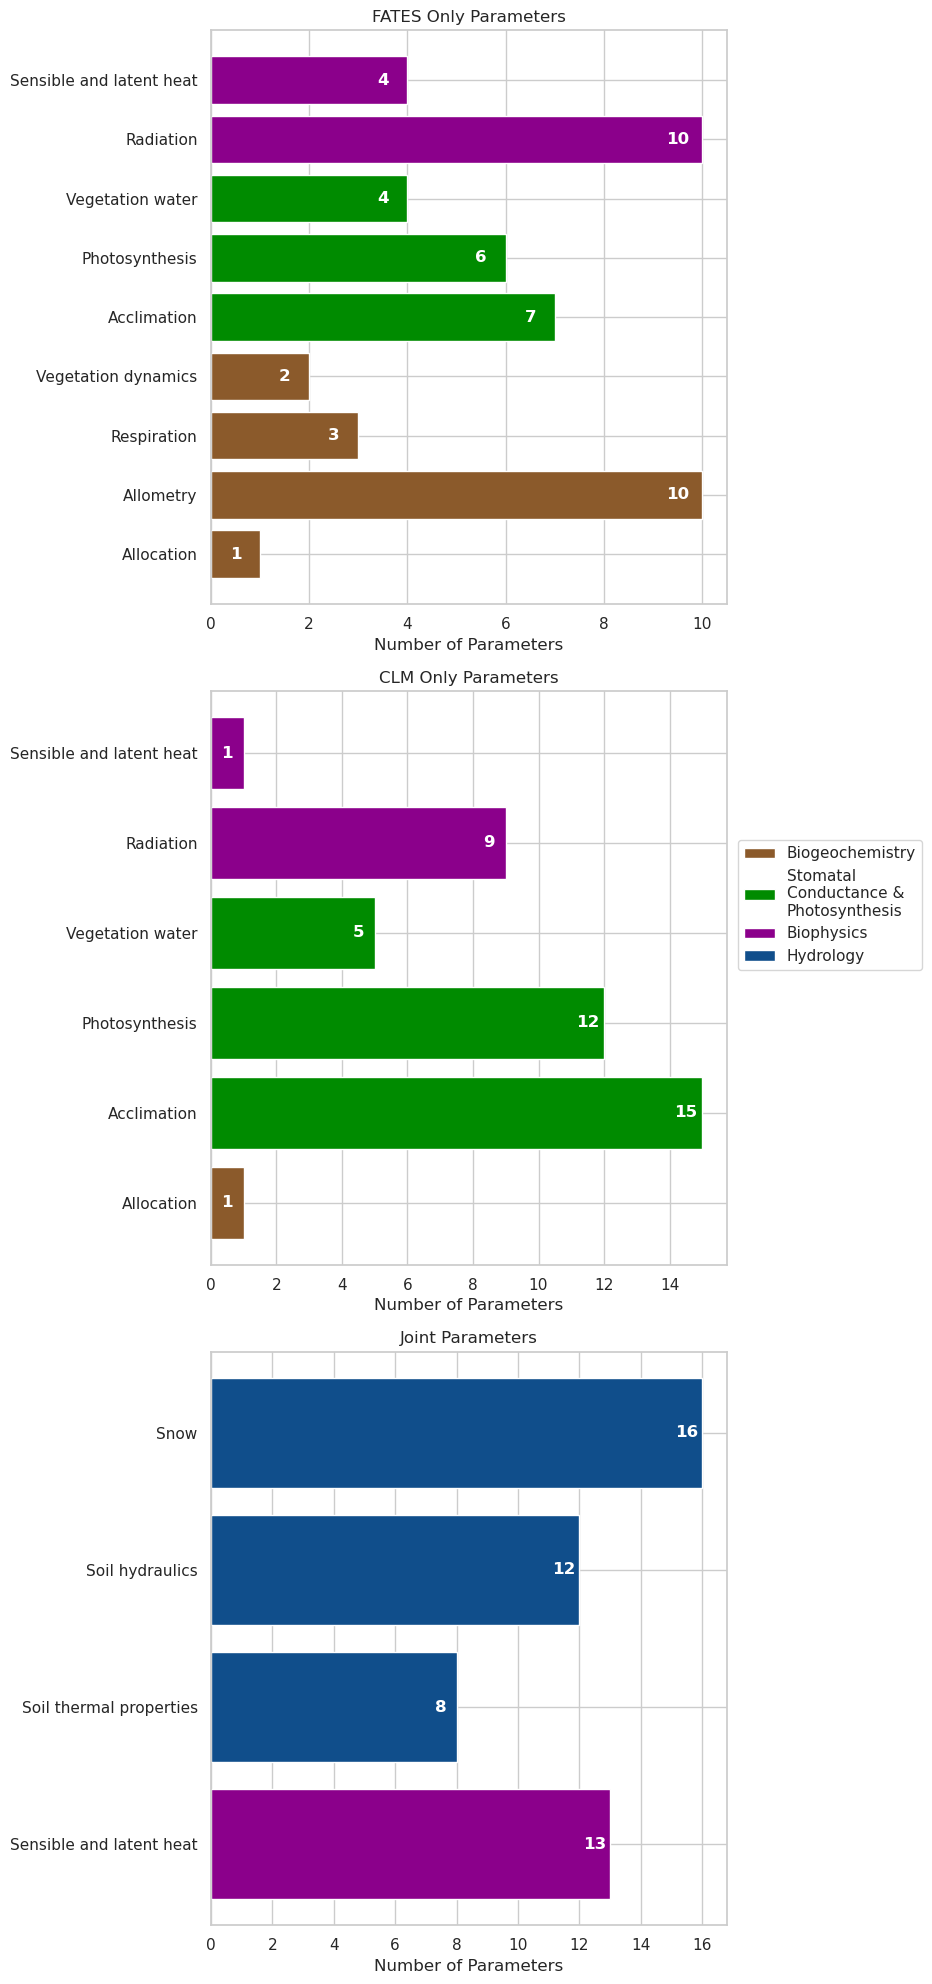

In [134]:
plot_oaat_params(param_dat_fates, param_dat_clm, param_dat_joint)
plt.savefig(os.path.join(fig_dir, 'oaat_parameters.png'))

In [24]:
# plotting.plot_oaat_params(fates_oaat_params.drop_duplicates(),
#                           'FATES PPE', clm_nonzero.drop_duplicates(),
#                           'CLM PPE')
# # plt.savefig(os.path.join(fig_dir, 'oaat_parameters.png'))

## Look at global annual ensemble ranges

In [18]:
vars = ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF', 'SOILWATER_10CM',
       'ASA', 'RN', 'BTRANMN', 'QRUNOFF', 'QSOIL', 'QVEGT',
       'QVEGE']
range_df = oaat.get_both_ranges(fates_ensemble, clm_ensemble, vars)

In [ ]:
oaat.print_ensemble_range(fates_ensemble, 'FATES', 'GPP', var_dict['GPP']['global_units'])

In [ ]:
oaat.print_ensemble_range(clm_ensemble, 'CLM', 'GPP', var_dict['GPP']['global_units'])

In [ ]:
oaat.print_ensemble_range(fates_ensemble, 'FATES', 'EFLX_LH_TOT', var_dict['EFLX_LH_TOT']['global_units'])

In [ ]:
oaat.print_ensemble_range(clm_ensemble, 'CLM', 'EFLX_LH_TOT', var_dict['EFLX_LH_TOT']['global_units'])

In [ ]:
oaat.print_ensemble_range(fates_ensemble, 'FATES', 'QVEGT', var_dict['QVEGT']['global_units'])

In [ ]:
oaat.print_ensemble_range(clm_ensemble, 'CLM', 'QVEGT', var_dict['QVEGT']['global_units'])

In [ ]:
variables = ['GPP', 'EFLX_LH_TOT', 'FSH']
plotting.plot_ensemble_variance(fates_ensemble, clm_ensemble,
                       'FATES', 'CLM', variables, var_dict)
plt.savefig(os.path.join(fig_dir, f'{"_".join(variables)}_ensemble_variance.png'))

In [ ]:
variables = ['QVEGE', 'QVEGT', 'QSOIL']
plotting.plot_ensemble_variance(fates_ensemble, clm_ensemble,
                       'FATES', 'CLM', variables, var_dict)
plt.savefig(os.path.join(fig_dir, f'{"_".join(variables)}_ensemble_variance.png'))

In [ ]:
variables = ['ASA', 'RN', 'TV']
plotting.plot_ensemble_variance(fates_ensemble, clm_ensemble,
                       'FATES', 'CLM', variables, var_dict)
plt.savefig(os.path.join(fig_dir, f'{"_".join(variables)}_ensemble_variance.png'))

In [ ]:
variables = ['QRUNOFF', 'BTRANMN', 'SOILWATER_10CM']
plotting.plot_ensemble_variance(fates_ensemble, clm_ensemble,
                       'FATES', 'CLM', variables, var_dict)
plt.savefig(os.path.join(fig_dir, f'{"_".join(variables)}_ensemble_variance.png'))

## Contribution to overall variance

In [ ]:
variable = 'QVEGE'
fates_var = oaat.get_param_variance(fates_pars, variable, fates_glob_combo, 0).sort_values('variance', ascending=False)
clm_var = oaat.get_param_variance(clm_pars, variable, clmbtran_glob, 0).sort_values('variance', ascending=False)

In [19]:
vars = ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF', 'SOILWATER_10CM',
       'ASA', 'RN', 'BTRANMN', 'QRUNOFF', 'QSOIL', 'QVEGT',
       'QVEGE']
variance_df_single = oaat.get_all_cumulative_variance(vars, clm_pars,
                                               clmbtran_glob, fates_pars, fates_glob_combo, 1)
pars_df = oaat.get_all_required(variance_df_single, vars)

In [ ]:
sns.barplot(data=pars_df, y='variable', x='parameters', hue='model')
plt.xlabel('# Parameters contributing to >90% of variance')
plt.ylabel(None);
plt.savefig(os.path.join(fig_dir, 'number_of_parameters.png'))

In [21]:
variance_df = oaat.get_all_cumulative_variance(['GPP', 'EF', 'ASA', 'SOILWATER_10CM', 'QVEGE', 'QVEGT'], clm_pars,
                                               clmbtran_glob, fates_pars, fates_glob_combo)

In [ ]:
plotting.plot_cumulative_variance(['GPP', 'EF', 'ASA', 'SOILWATER_10CM', 'QVEGE', 'QVEGT'], variance_df)
plt.savefig(os.path.join(fig_dir, 'variance_explained.png'))

## Top Parameters

In [22]:
# global min max differences
fates_meandiffs = oaat.get_min_max_diff(fates_combo_mean)
fates_meandiffs['parameter'] = fates_meandiffs.index
fates_meandiffs['model'] = 'FATES'

clm_meandiffs = oaat.get_min_max_diff(clmbtran_mean)
clm_meandiffs['parameter'] = clm_meandiffs.index
clm_meandiffs['model'] = 'CLM'

In [ ]:
output_groups = {
    'Carbon fluxes': ['GPP'],
    'Energy fluxes': ['FSH', 'EFLX_LH_TOT', 'QVEGT', 'QVEGE', 'EF', 'ASA', 'FSA',
                     'FIRE', 'RLNS', 'RN', 'TV'],
    'Water fluxes': ['BTRANMN', 'SOILWATER_10CM', 'QSOIL', 'QRUNOFF'],
}

In [ ]:
vars = ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF', 'SOILWATER_10CM',
       'ASA', 'RN', 'RLNS', 'BTRANMN', 'QRUNOFF', 'QSOIL', 'QVEGT',
        'TV', 'QVEGE']

In [ ]:
top_clm_params = {}
for variable in vars:
    clm_top10 = oaat.get_top_n(clmbtran_mean, clm_meandiffs, variable, 10, clmbtran_mean.sel(ensemble=0))
    top_clm_params[variable] = clm_top10.parameter_name.values

In [ ]:
top_fates_params = {}
for variable in vars:
    fates_top10 = oaat.get_top_n(fates_combo_mean, fates_meandiffs, variable, 10, fates_combo_mean.sel(ensemble=0))
    top_fates_params[variable] = fates_top10.parameter_name.values

In [ ]:
top_fates_df = oaat.get_param_counts_in_top_n(top_fates_params)
top_clm_df = oaat.get_param_counts_in_top_n(top_clm_params)
top_fates_df = pd.merge(top_fates_df, all_params, left_on='parameter', right_on='parameter_name')
top_clm_df = pd.merge(top_clm_df, all_params, left_on='parameter', right_on='parameter_name')

In [ ]:
variable = 'FSA'
fates_top10 = oaat.get_top_n(fates_combo_mean, fates_meandiffs, variable, 10, fates_combo_mean.sel(ensemble=0))
clm_top10 = oaat.get_top_n(clmbtran_mean, clm_meandiffs, variable, 10, clmbtran_mean.sel(ensemble=0))
plotting.plot_2_top_n(fates_top10, clm_top10, fates_combo_mean.sel(ensemble=0), 
             clmbtran_mean.sel(ensemble=0), variable, var_dict[variable]['long_name'],
             var_dict[variable]['global_units'])
plt.savefig(os.path.join(fig_dir, f'{variable}_top_10.png'))

### By Biome

In [ ]:
def get_biome_df(biome_ds):
    biomes = biome_ds.biome.values
    biome_diffs = []
    for biome in biomes:
        df = oaat.get_min_max_diff(biome_ds.sel(summation_var='mean').sel(biome=biome))
        df['biome'] = biome
        biome_diffs.append(df)
    return pd.concat(biome_diffs)

In [ ]:
def get_biome_top_n(biome_ds, biome_df, variable, n=10):
    biomes = biome_ds.biome.values
    topns = []
    for biome in biomes:
        biome_mean = biome_ds.sel(summation_var='mean').sel(biome=biome)
        diff_df = biome_df[biome_df.biome == biome]
        top_n = oaat.get_top_n(biome_mean, diff_df, variable, n, biome_mean.sel(ensemble=0))
        top_n['biome'] = biome
        topns.append(top_n)
    return pd.concat(topns)

In [ ]:
importlib.reload(plotting)
importlib.reload(oaat)

In [ ]:
fates_biome_df = get_biome_df(fates_biome_combo)
clm_biome_df = get_biome_df(clm_biome)

In [ ]:
variable = 'GPP'
fates_biome_top10 = get_biome_top_n(fates_biome_combo, fates_biome_df, variable)
clm_biome_top10 = get_biome_top_n(clm_biome, clm_biome_df, variable)

In [ ]:
plotting.plot_top_n(fates_biome_top10, fates_biome_combo.sel(summation_var='mean').sel(ensemble=0), variable, 
                    var_dict[variable]['long_name'], 
                    var_dict[variable]['global_units'], by_biomes=True)
plt.savefig(os.path.join(fig_dir, f'{variable}_top_10_FATES_by_biome.png'))

In [ ]:
plotting.plot_top_n(clm_biome_top10, clm_biome.sel(summation_var='mean').sel(ensemble=0), variable, 
                    var_dict[variable]['long_name'], 
                    var_dict[variable]['global_units'], by_biomes=True)
plt.savefig(os.path.join(fig_dir, f'{variable}_top_10_CLM_by_biome.png'))

## Differences between models

In [ ]:
importlib.reload(oaat)

In [211]:
 415000 - 196562.5

218437.5

In [ ]:
importlib.reload(plotting)

In [210]:
fates_glob_combo.where(fates_glob_combo.parameter_name == 'fates_leaf_vcmaxhd', drop=True).sel(summation_var='mean').GPP

<xarray.DataArray 'GPP' (ensemble: 2)>
array([165.1147669 , 165.11416777])
Coordinates:
  * ensemble       (ensemble) int64 121 122
    summation_var  <U4 'mean'

In [125]:
vars = ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF', 'SOILWATER_10CM',
       'ASA', 'RN', 'RLNS', 'BTRANMN', 'QRUNOFF', 'QSOIL', 'QVEGT',
        'TV', 'QVEGE']
importlib.reload(oaat)
clm_reldiffs, fates_reldiffs, fatesclm_reldiffs = oaat.get_all_vardiffs(vars, clmbtran_glob, fates_glob_combo, fates_glob,
                     nonzero_params, 20, reldiff=True)

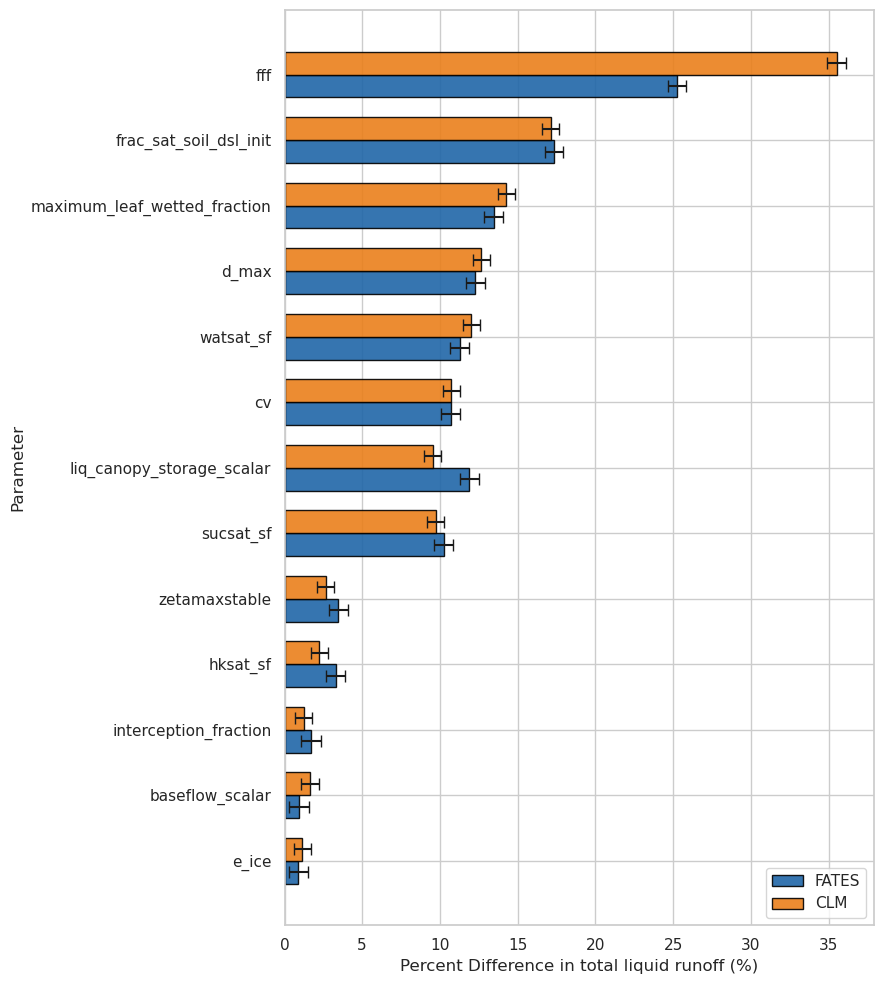

In [275]:
variable = 'QRUNOFF'
importlib.reload(plotting)
plotting.plot_var_diff(fatesclm_reldiffs, variable, 1, var_dict[variable]['long_name'], include_sd=True)
# # plt.savefig(os.path.join(fig_dir, f'{variable}_FATES_CLM_compare.png'))

In [182]:
def get_compare_df(clm_reldiffs, fates_reldiffs, clm_parameter, fates_parameter):
    clm_sub = clm_reldiffs[clm_reldiffs.parameter == clm_parameter].reset_index().drop(columns=['parameter', 'index'])
    fates_sub = fates_reldiffs[fates_reldiffs.parameter == fates_parameter].reset_index().drop(columns=['parameter', 'index'])
    
    both_sub = pd.concat([clm_sub, fates_sub]).melt(id_vars=['model'])
    both_sub[['base_var', 'stat']] = both_sub['variable'].str.extract(r'(.*)_(mean|sd)')
    df_wide = both_sub.pivot_table(index=['model', 'base_var'], columns='stat', values='value').reset_index()
    df_wide.columns.name = None
    df_wide = df_wide.rename(columns={'mean': 'mean_value', 'sd': 'sd_value', 'base_var': 'variable'})

    return df_wide

def plot_compare_vars(df, clm_param, fates_param):
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df,
        x='variable',
        y='mean_value',
        hue='model',
        palette=plotting._MODEL_COLS,
        dodge=True,
        errorbar=None 
    )
    
    # Add error bars manually
    # Calculate positions of bars
    n_models = df['model'].nunique()
    bar_width = 0.8 / n_models
    variable_order = df['variable'].unique()
    
    x_ticks = []
    for i, var in enumerate(variable_order):
        for j, model in enumerate(df['model'].unique()):
            x = i - 0.4 + (j + 0.5) * bar_width
            y = df[(df['variable'] == var) & (df['model'] == model)]['mean_value'].values[0]
            yerr = df[(df['variable'] == var) & (df['model'] == model)]['sd_value'].values[0]
            plt.errorbar(x, y, yerr=np.abs(yerr), fmt='none', ecolor='black', capsize=4)
            x_ticks.append(x)
    
    plt.xticks(ticks=range(len(variable_order)), labels=variable_order, rotation=45, ha='right')
    plt.ylabel("Mean Percent Difference (%)")
    plt.xlabel(None)
    plt.title(f'FATES parameter: {fates_param} \n CLM parameter: {clm_param}')
    plt.tight_layout()

In [188]:
corresponding_params = {'dleaf': 'fates_turb_leaf_diameter',  # virtually the same
                       'fnps': 'fates_leaf_fnps',             # about the same, considering different ranges
                       'jmaxha': 'fates_leaf_jmaxha',         ## LOOK AT THIS ONE
                       'jmaxhd': 'fates_leaf_jmaxhd',         ## LOOK AT THIS ONE
                       'jmaxse_sf': 'fates_leaf_jmaxse',      ## LOOK AT THIS ONE
                       'medlynintercept': 'fates_leaf_stomatal_intercept', ## LOOK AT THIS ONE
                       'medlynslope': 'fates_leaf_stomatal_slope_medlyn', ## some diffs?
                       'rholnir': 'fates_rad_leaf_rhonir',  # same
                       'rholvis': 'fates_rad_leaf_rhovis',   ## LOOK AT THIS ONE
                       'rhosnir': 'fates_rad_stem_rhonir',   # same
                       'rhosvis': 'fates_rad_stem_rhovis',   # same 
                       'slatop': 'fates_leaf_slatop',        ## LOOK AT THIS ONE - may need to re-do
                       'smpsc': 'fates_nonhydro_smpsc',     # same
                       'smpso': 'fates_nonhydro_smpso',     # same
                       'taulnir': 'fates_rad_leaf_taunir',  # same
                       'taulvis': 'fates_rad_leaf_tauvis',  # same
                       'tausnir': 'fates_rad_stem_taunir',  # same
                       'tausvis': 'fates_rad_stem_tauvis',  # same
                       'vcmaxha': 'fates_leaf_vcmaxha',    # not super different
                       'vcmaxhd': 'fates_leaf_vcmaxhd',    ## LOOK AT THIS ONE
                       'vcmaxse_sf': 'fates_leaf_vcmaxse',  # sort of different?
                       'xl': 'fates_rad_leaf_xl'}         # same

clm_params = list(corresponding_params.keys())

In [ ]:
# increase light scattering lower in canopy
# FATES uses this light more than CLM ? 

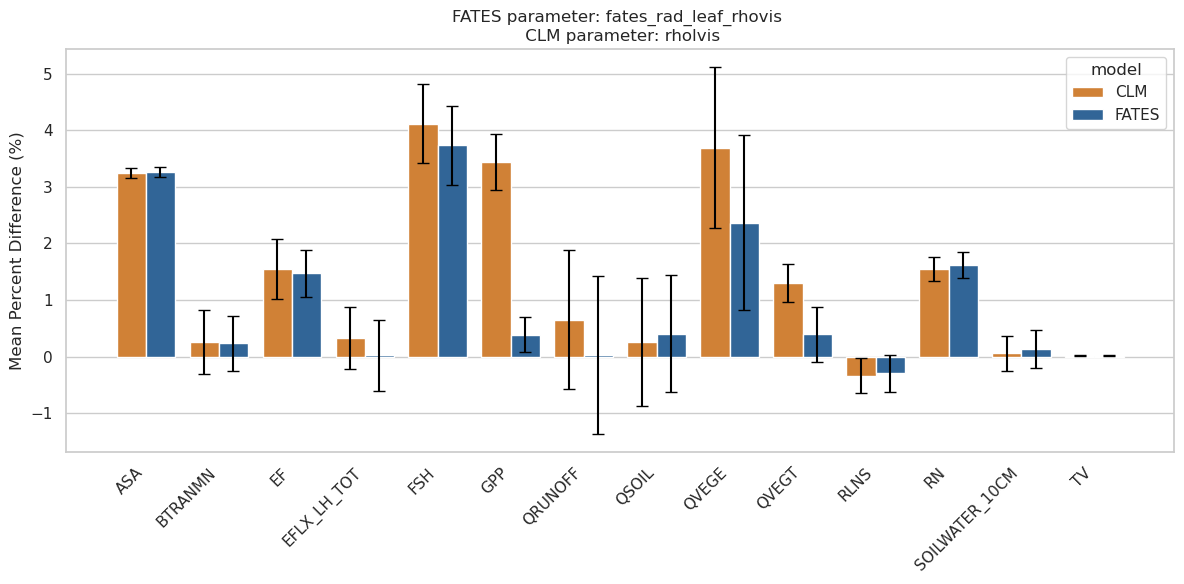

In [292]:
clm_parameter = 'rholvis'
fates_parameter = corresponding_params[clm_parameter]
df = get_compare_df(clm_reldiffs, fates_reldiffs, clm_parameter, fates_parameter)
plot_compare_vars(df, clm_parameter, fates_parameter)
plt.savefig(os.path.join(fig_dir, f'{fates_parameter}_{clm_parameter}_FATES_CLM_compare.png'))

### Maps

In [221]:
def get_parameter_data(parameter, fates_maps, fate_clm_maps, clm_maps):
    if parameter in nonzero_params['fates_only']:
        dat_fates = fates_maps.where(fates_maps.parameter_name == parameter, drop=True)
        dat_clm = None
    elif parameter in nonzero_params['fates_clm']:
        dat_fates = fate_clm_maps.where(fate_clm_maps.parameter_name == parameter, drop=True)
        dat_clm = clm_maps.where(clm_maps.parameter_name == parameter, drop=True)
    else:
        dat_clm = clm_maps.where(clm_maps.parameter_name == parameter, drop=True)
        dat_fates = None

    return dat_fates, dat_clm

In [216]:
# create a global land frac and area grid
land_frac_ds = os.path.join("/glade/derecho/scratch/afoster/archive",
                            "ctsm60SP_bigleaf_fullgrid/lnd/hist",
                            "ctsm60SP_bigleaf_fullgrid.clm2.h0.0001-02-01-00000.nc")
target_grid = clm.create_target_grid(land_frac_ds, 'FSR')
ds_frac = xr.Dataset({'landfrac': target_grid.landfrac,
                'landarea': target_grid.land_area})

In [217]:
fates_maps = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_annual_maps.nc"))
fates_maps_ens = fates_maps.where(fates_maps.ensemble > fates['default'], drop=True)
fates_maps_ens = xr.merge([fates_maps_ens, fates_param_dat])

In [218]:
fates_clm_maps = xr.open_dataset(os.path.join(hist_dir, f"{fates_clm['name']}_annual_maps.nc"))
fates_clm_maps_ens = fates_clm_maps.where(fates_clm_maps.ensemble > fates_clm['default'], drop=True)
fates_clm_maps_ens = xr.merge([fates_clm_maps_ens, clm_param_dat])

In [219]:
clm_maps = xr.open_dataset(os.path.join(hist_dir, f"{clm_btran['name']}_annual_maps.nc"))
clm_maps_ens = clm_maps.where(clm_maps.ensemble > clm_btran['default'], drop=True)
clm_maps_ens = xr.merge([clm_maps_ens, clm_param_dat])

In [285]:
_, clm_dat = get_parameter_data('rholvis', fates_maps_ens, fates_clm_maps_ens, clm_maps_ens)
fates_dat, _ = get_parameter_data('fates_rad_leaf_rhovis', fates_maps_ens, fates_clm_maps_ens, clm_maps_ens)

In [289]:
variable = 'GPP'
parameter = 'rholvis'
fates_diff = fates_dat[variable].isel(ensemble=1)*ds_frac.landfrac - fates_dat[variable].isel(ensemble=0)*ds_frac.landfrac
clm_diff = clm_dat[variable].isel(ensemble=1)*ds_frac.landfrac - clm_dat[variable].isel(ensemble=0)*ds_frac.landfrac

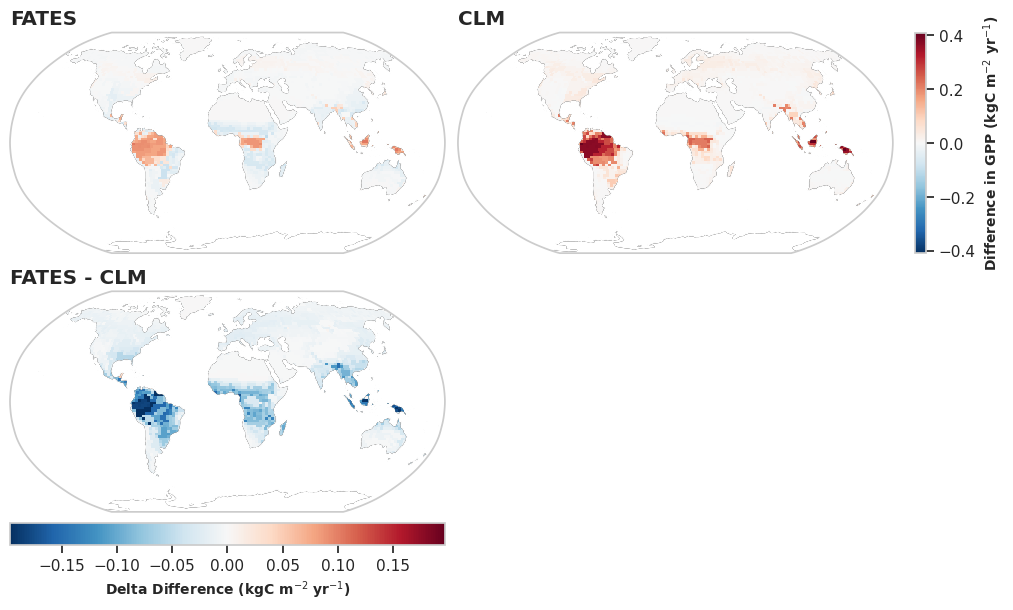

In [290]:
plotting.plot_two_model_diff(clm_diff, fates_diff,
                             'CLM', 'FATES', var_dict[variable]['long_name'],
                             var_dict[variable]['annual_units'], 'RdBu_r', True, 'diff')
plt.savefig(os.path.join(fig_dir, f'{variable}_{parameter}_FATES_CLM_compare_glob.png'))

### Climatology

In [ ]:
clim_fates = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_climatology.nc"))
clim_fates_ens = clim_fates.where(clim_fates.ensemble > fates['default'], drop=True)
clim_fates_ens = xr.merge([clim_fates_ens, fates_param_dat])

clim_fates_clmpars = xr.open_dataset(os.path.join(hist_dir, f"{fates_clm['name']}_climatology.nc"))
clim_fates_clmpars_ens = clim_fates_clmpars.where(clim_fates_clmpars.ensemble > fates_clm['default'], drop=True)
clim_fates_clmpars_ens = xr.merge([clim_fates_clmpars_ens, clm_param_dat])

clim_clm = xr.open_dataset(os.path.join(hist_dir, f"{clm_btran['name']}_climatology.nc"))
clim_clm_ens = clim_clm.where(clim_clm.ensemble > clm_btran['default'], drop=True)
clim_clm_ens = xr.merge([clim_clm_ens, clm_param_dat])

In [ ]:
variable = 'GPP'
plotting.plot_oaat_climatology(clim_clm_ens, clim_clm.isel(ensemble=0),
                               variable, var_dict[variable]['long_name'],
                               var_dict[variable]['global_units'], None)

In [ ]:
variable = 'GPP'
plotting.plot_oaat_climatology(clim_fates_ens, clim_fates.isel(ensemble=0),
                               variable, var_dict[variable]['long_name'],
                               var_dict[variable]['global_units'], None)

### Zonal Means

In [ ]:
zonal_fates = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_zonal_means.nc"))
zonal_fates_ens = zonal_fates.where(zonal_fates.ensemble > fates['default'], drop=True)
zonal_fates_ens = xr.merge([zonal_fates_ens, fates_param_dat])

In [ ]:
variable = 'EFLX_LH_TOT'
plotting.plot_oaat_zonal(zonal_fates_ens, zonal_fates.sel(ensemble=0), variable,
                     var_dict[variable]['long_name'], var_dict[variable]['annual_units'])